In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

In [2]:
def parse_data_file(filename):
    # Чтение файла и парсинг данных по каналам без сохранения во временные csv
    with open(filename, "r") as raw_data:
        channel_data = {}
        headers = {}
        channel_order = []
        while True:
            line = raw_data.readline()
            if not line:
                break
            if line.startswith("#CHANNEL"):
                ch = line.split(":")[1].strip()
                channel_order.append(ch)
                size_line = raw_data.readline()
                size = int(size_line.strip().split('=')[1])
                header_line = raw_data.readline().strip().split(",")
                headers[ch] = header_line
                channel_data[ch] = []
                for i in range(size):
                    data_line = raw_data.readline().strip().split(",")
                    channel_data[ch].append(data_line)
    # Преобразуем данные каналов в DataFrame
    dfs = {}
    for ch in channel_order:
        dfs[ch] = pd.DataFrame(channel_data[ch], columns=headers[ch])
        for col in dfs[ch].columns:
            dfs[ch][col] = pd.to_numeric(dfs[ch][col], errors='coerce')
    # Собираем итоговый DataFrame
    data = pd.DataFrame()
    # Предполагаем, что первый канал содержит время
    time_col = None
    for col in dfs[channel_order[0]].columns:
        if "Time" in col:
            time_col = col
            break
    if time_col is None:
        raise ValueError("Не найден столбец времени в первом канале")
    data["Time, s"] = dfs[channel_order[0]][time_col]
    # Добавляем все каналы
    for idx, ch in enumerate(channel_order):
        volt_col = None
        for col in dfs[ch].columns:
            if "Volt" in col:
                volt_col = col
                break
        if volt_col is not None:
            data[f"V_{idx+1}"] = dfs[ch][volt_col]
    return data


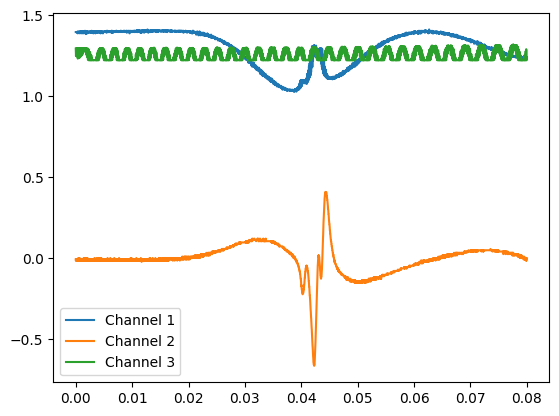

In [3]:
data_1 = parse_data_file("85_F3_SD.txt")
plt.plot(data_1["Time, s"], data_1["V_1"], label="Channel 1")
plt.plot(data_1["Time, s"], data_1["V_2"], label="Channel 2")
plt.plot(data_1["Time, s"], data_1["V_3"], label="Channel 3")
#plt.plot(data_1["Time, s"], data_1["V_4"], label="Channel 1")
plt.legend()

In [4]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt


c = 299792458
a = 1
dnu = c/(4*a)
print(dnu*1E-6, 'MHz') # частоты между пиками интерферометра


def find_peaks_and_make_nu(data):
    x = data["Time, s"]
    y = data["Interferometer"]
    
    # Находим пики (локальные максимумы)
    peaks, properties = sp.signal.find_peaks(
        np.array(y),   
        distance=10,          # минимум 10 точек между пиками
        prominence=0.005,     # минимальная "выдающаяся" высота
        width=1
    )

    # Визуализируем результат
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x, y, 'b-', linewidth=1, label='Исходная кривая')
    ax.plot(np.array(x)[peaks], np.array(y)[peaks], "rx", 
            markersize=8, markeredgewidth=2, label='Найденные пики')
    
    # Расчет расстояний между пиками
    peaks_x = np.array(x)[peaks]
    distances = np.diff(peaks_x)  # более элегантный способ
    
    # Добавляем информацию о расстояниях на график
    for i in range(len(peaks_x)-1):
        mid_x = (peaks_x[i] + peaks_x[i+1]) / 2
        mid_y = (np.array(y)[peaks[i]] + np.array(y)[peaks[i+1]]) / 2
        ax.annotate(f'{distances[i]*10000:.2f}', 
                   xy=(mid_x, mid_y), 
                   xytext=(0, 10), 
                   textcoords='offset points',
                   ha='center', fontsize=8, color='green')
    
    # # Вывод отладочной информации
    # print(f"Всего найдено пиков: {len(peaks)}")
    # print(f"Первые 5 расстояний (x10000): {distances[:5]*10000}")
    # print(f"Последние 5 расстояний (x10000): {distances[-5:]*10000}")
    
    # # Статистика
    # print(f"\nСтатистика расстояний:")
    # print(f"  Среднее: {np.mean(distances)*10000:.2f}")
    # print(f"  Std: {np.std(distances)*10000:.2f}")
    # print(f"  Мин: {np.min(distances)*10000:.2f}")
    # print(f"  Макс: {np.max(distances)*10000:.2f}")
    
    # Оформление графика
    ax.set_xlabel("Time, s", fontsize=12)
    ax.set_ylabel("$V_{интерферометра}$, В", fontsize=12)
    ax.set_title(f"Найденные пики (всего: {len(peaks)})", fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.close()
    # plt.tight_layout()
    # plt.show()
    
    return peaks_x, distances, fig


def data_parse(file_name, show_plots=False):
    raw_data = parse_data_file(file_name)
    data = pd.DataFrame()
    data["Time, s"] = raw_data["Time, s"]
    data["Interferometer"] = raw_data["V_3"]
    data["PD"] = raw_data["V_1"]
    data["SD"] = raw_data["V_2"]


    b, a = sp.signal.butter(3, [0.01,100000], btype='band', fs=1000000)
    data["Interferometer"] = sp.signal.filtfilt(b, a, data["Interferometer"])
    peaks_x, distances, fig_peaks = find_peaks_and_make_nu(data)
    def delta_nu(t):
        if t < peaks_x[0]:
            # Extrapolate using first interval
            dt = peaks_x[1] - peaks_x[0]
            fraction = (t - peaks_x[0]) / dt
            return dnu * fraction
        elif t > peaks_x[-1]:
            # Extrapolate using last interval
            dt = peaks_x[-1] - peaks_x[-2]
            fraction = (t - peaks_x[-1]) / dt
            return dnu * (len(peaks_x) - 1 + fraction)
        else:
            # Original logic
            i = len(peaks_x[peaks_x < t]) - 1
            fraction = (t - peaks_x[i]) / (peaks_x[i+1] - peaks_x[i])
            return dnu * (i + fraction)
    
    
    data["nu"] = data["Time, s"].apply(delta_nu)
    
    fig_PD, (ax_PD, ax_PD_2) = plt.subplots(2, 1, figsize=(12, 6))
    ax_PD.plot(data["nu"], data["PD"], label="PD")
    ax_PD_2.plot(data["nu"], data["SD"], label="SD")
    ax_PD.set_xlabel("Частота, МГц")
    ax_PD.set_ylabel("Напряжение, В")
    ax_PD.legend()
    ax_PD.grid()
    plt.close()
    if show_plots:
        display(fig_PD, fig_peaks)
    return data


data = data_parse("87f2.txt")
data 

74.9481145 MHz


,"Time, s",Interferometer,PD,SD,nu
0,0.00000,-0.112913,1.094,-0.112,-2.025625e+06
1,0.00002,-0.108604,1.094,-0.104,-1.350416e+06
2,0.00004,-0.105874,1.098,-0.104,-6.752082e+05
3,0.00006,-0.105574,1.094,-0.104,0.000000e+00
4,0.00008,-0.107566,1.096,-0.096,6.752082e+05
...,...,...,...,...,...
3995,0.07990,-0.060073,1.228,0.056,2.181746e+09
3996,0.07992,-0.057941,1.230,0.056,2.182434e+09
3997,0.07994,-0.055280,1.236,0.056,2.183122e+09
3998,0.07996,-0.052207,1.236,0.056,2.183809e+09


In [5]:
data_general_picture = data_parse("General_sd_picture.txt", show_plots=False)
data_85f3 = data_parse("norm_85_f3.txt", show_plots=False)
data_85f3["SD"] = data_85f3["SD"]
data_87f2_better = data_parse("87f2_better.txt", show_plots=False)


Initial parameters:

Fit parameters:
Baseline (Polynomial order 6): [-2.25152663e+01  1.14981713e-01 -2.34348145e-04  2.43786310e-07
 -1.36798636e-10  3.94215566e-14 -4.57754055e-18]
Peak 1: A=51.866403, x0=1185.83, gamma=29.73
Peak 2: A=237.711821, x0=1321.91, gamma=38.95
Peak 3: A=106.503289, x0=1399.63, gamma=32.28
Peak 4: A=67.994531, x0=1456.46, gamma=40.17
Peak 5: A=61.572949, x0=1536.69, gamma=35.61
Peak 6: A=10.938398, x0=1616.31, gamma=31.59


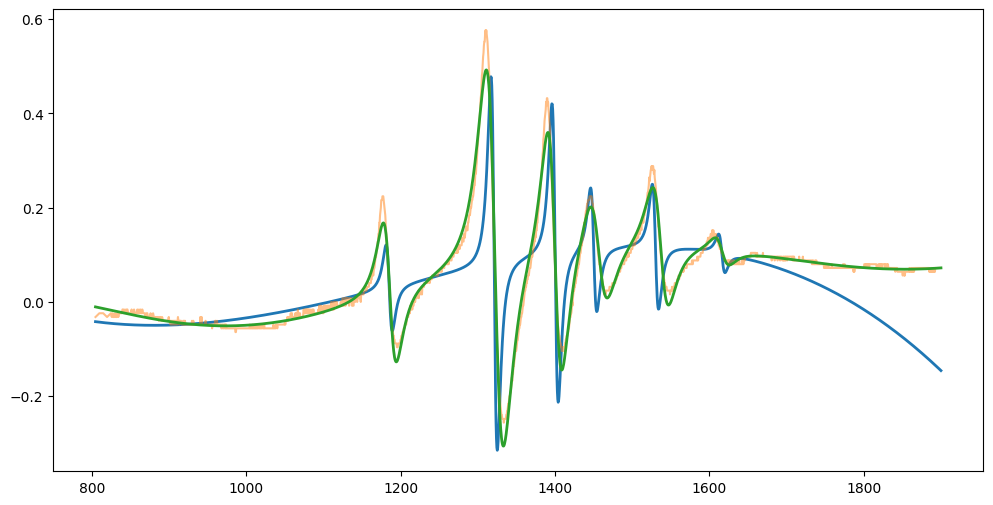

Пэ


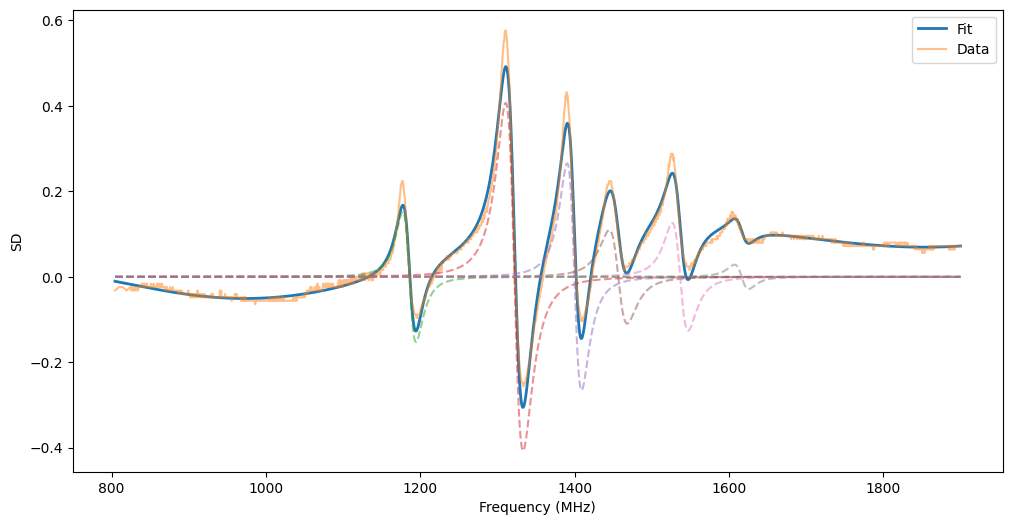

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ---------- Модели ----------

def gaussian_derivative(x, A, x0, sigma):
    return A * (x - x0) / sigma**2 * np.exp(-(x - x0)**2 / (2 * sigma**2))


def lorentzian_derivative(x, A, x0, gamma):
    return -A * gamma *(x - x0) / ((x - x0)**2 + gamma**2/4)**2


def polynomial(x, *coeffs):
    return sum(c * x**i for i, c in enumerate(coeffs))


# ---------- Общая модель ----------

def build_model(n_peaks=4, baseline="poly", poly_order=2):

    def model(x, *params):

        idx = 0

        # baseline
        if baseline == "gaussian":
            A, x0, sigma = params[idx:idx+3]
            y = gaussian_derivative(x, A, x0, sigma)
            idx += 3

        elif baseline == "poly":
            coeffs = params[idx:idx+poly_order+1]
            y = polynomial(x, *coeffs)
            idx += poly_order + 1

        else:
            y = 0

        # пики
        for _ in range(n_peaks):
            A, x0, gamma = params[idx:idx+3]
            y += lorentzian_derivative(x, A, x0, gamma)
            idx += 3

        return y

    return model


# ---------- Основная функция ----------

def fit_saturated_absorption(
    data,
    n_peaks=5,
    baseline="gaussian",
    poly_order=2,
    peak_range=None,
    initial_params=None,
    plot_peaks=True
):

    d = data.copy()

    # --- сразу переводим в МГц ---
    d["nu_MHz"] = d["nu"] / 1e6

    if peak_range:
        d = d[(d["nu_MHz"] > peak_range[0]) &
              (d["nu_MHz"] < peak_range[1])]

    x = d["nu_MHz"].values
    y = d["SD"].values

    model = build_model(n_peaks, baseline, poly_order)

    # ---------- начальные параметры ----------
    if initial_params is None:

        params = []

        # baseline
        if baseline == "gaussian":
            params += [0.01, np.mean(x), 200]

        elif baseline == "poly":
            params += [0]*(poly_order+1)

        # пики
        peak_positions = np.linspace(x.min(), x.max(), n_peaks)

        for pos in peak_positions:
            params += [0.005, pos, 20]

        initial_params = params

    print("\nInitial parameters:")


    x_fit = np.linspace(x.min(), x.max(), 2000)
    y_init = model(x_fit, *initial_params)
    plt.figure(figsize=(12,6))
    plt.plot(x_fit, y_init, label="Initial", linewidth=2)

    plt.plot(x, y, label="Data", alpha=0.5)

    # ---------- фит ----------
    popt, pcov = curve_fit(
        model,
        x,
        y,
        p0=initial_params,
        maxfev=5000
    )

    print("\nFit parameters:")
    idx = 0
    if baseline == "gaussian":
        print(f"Baseline (Gaussian): A={popt[idx]:.6f}, x0={popt[idx+1]:.2f}, sigma={popt[idx+2]:.2f}")
        idx += 3
    elif baseline == "poly":
        coeffs = popt[idx:idx+poly_order+1]
        print(f"Baseline (Polynomial order {poly_order}): {coeffs}")
        idx += poly_order + 1
    for i in range(n_peaks):
        A, x0, gamma = popt[idx:idx+3]
        print(f"Peak {i+1}: A={A:.6f}, x0={x0:.2f}, gamma={gamma:.2f}")
        idx += 3


    # ---------- графики ----------

    y_fit = model(x_fit, *popt)


    plt.plot(x_fit, y_fit, label="Fit", linewidth=2)

    plt.show()


    plt.figure(figsize=(12,6))
    plt.grid(True)
    
    plt.plot(x_fit, y_fit, label="Fit", linewidth=2)
    plt.plot(x, y, label="Data", alpha=0.5)

    # ---------- отдельные пики ----------
    if plot_peaks:

        idx = 0

        if baseline == "gaussian":
            idx += 3
        elif baseline == "poly":
            idx += poly_order + 1

        for i in range(n_peaks):
            A, x0, gamma = popt[idx:idx+3]
            peak = lorentzian_derivative(x_fit, A, x0, gamma)
            plt.plot(x_fit, peak, "--", alpha=0.5)

            idx += 3

    plt.xlabel("Frequency (MHz)")
    plt.ylabel("SD")
    plt.legend()
    plt.grid()


    return popt, pcov



initial = [

# polynomial baseline (3 степень)
1.82064603e+00, -5.27195092e-03,  4.73680929e-06, -1.31936673e-09,0,0,0,

# пики
7, 1185, 14,
30, 1321, 14,
24, 1400, 14,
10, 1450, 14,
10, 1530, 14,
3, 1616, 14,
]

peak_popt, _ =fit_saturated_absorption(
    data_87f2_better,
    n_peaks=6,
    baseline="poly",
    poly_order=6,
    peak_range=(800,1900),
    initial_params=initial
)
peak_popt = peak_popt[7:]  # убираем коэффициенты полинома

print("Пэ")

[  0.   133.32 211.79 266.64 345.11 423.58]


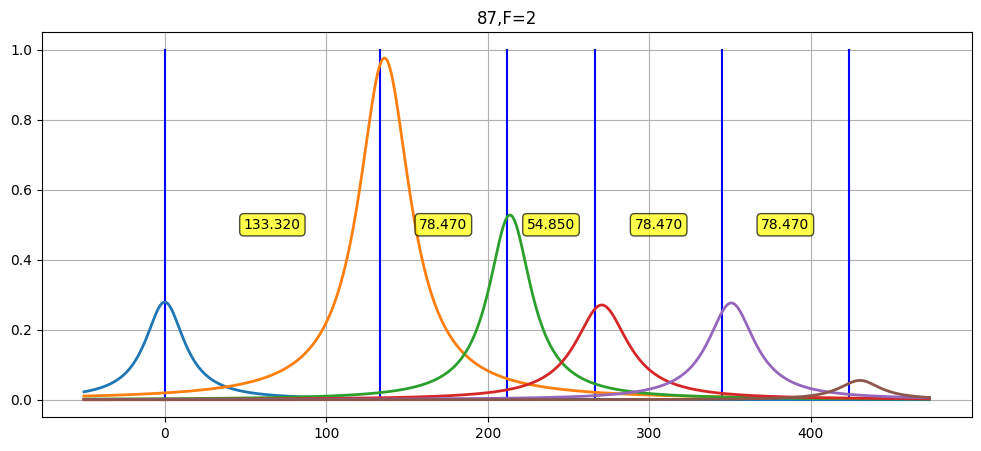

In [7]:
import matplotlib.pyplot as plt
import numpy as np


def lorentzian(x, A, x0, gamma):
    return A * gamma / ((x - x0)**2 + gamma**2/4)


def plot(freq, title, peak_params=None):

    y = np.linspace(0, 1, 20)

    dots = [
        0,
        freq[0]/2,
        freq[0],
        (freq[0]+freq[1])/2,
        (freq[0]+freq[1]),
        freq[0]+(freq[1])/2
    ]

    dots = np.sort(dots)
    print(dots)

    lines = np.array([np.ones(20)*i for i in dots])

    plt.figure(figsize=(12,5))

    # вертикальные линии
    for i in lines:
        plt.plot(i, y, color='blue')

    # расстояния
    for i in range(len(dots)-1):
        mid_x = (dots[i] + dots[i+1]) / 2
        distance = dots[i+1] - dots[i]

        plt.text(
            mid_x,
            0.5,
            f'{distance:.3f}',
            horizontalalignment='center',
            verticalalignment='center',
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='yellow',
                alpha=0.7
            )
        )

    # ---------- лоренцевские профили ----------
    if peak_params is not None:

        x = np.linspace(min(dots)-50, max(dots)+50, 2000)

        idx = 0

        for i in range(len(peak_params)//3):

            A, x0, gamma = peak_params[idx:idx+3]

            y_lor = lorentzian(x, A, x0, gamma)

            # нормировка
            #y_lor = y_lor / np.max(y_lor)
            y_lor = y_lor * 0.04  # масштабируем для лучшей видимости

            plt.plot(x, y_lor, linewidth=2)

            idx += 3

    plt.title(title)
    plt.grid()
    plt.show()
x0 = peak_popt[1]
for i in range(1, len(peak_popt), 3):
    peak_popt[i] = peak_popt[i] - x0  # переводим x0 в МГц
freq1 = np.array([229.85-72.91,193.74+72.9][::-1])
plot(freq1, '87,F=2', peak_popt)

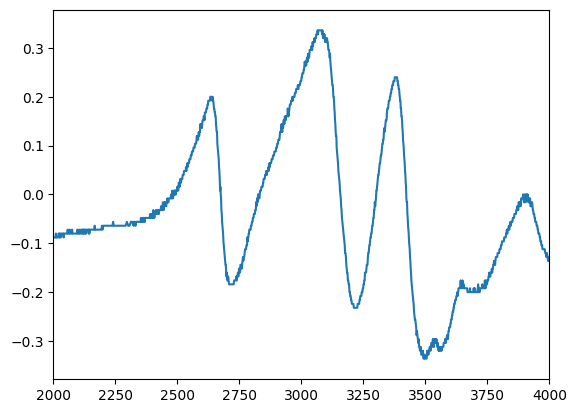

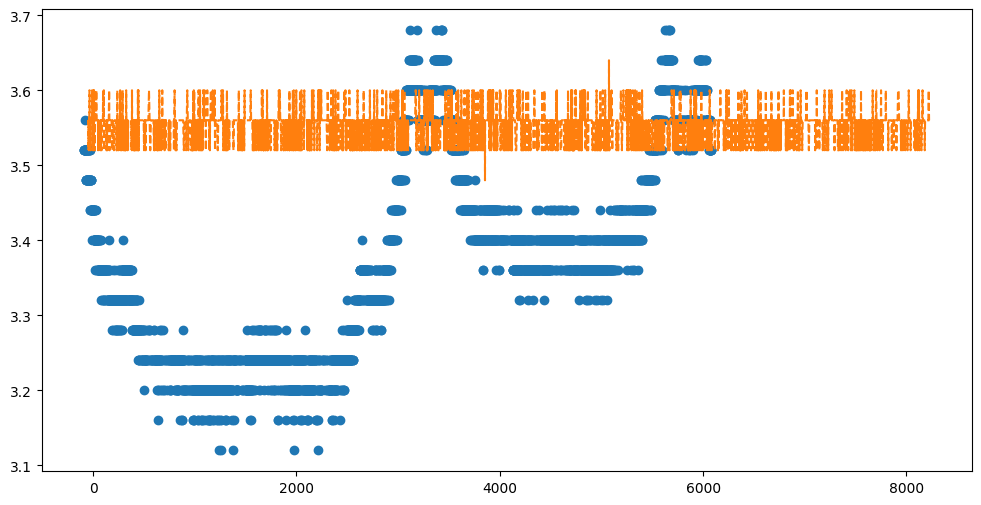

In [8]:
data_stab_ad_gain = data_parse("stabilization_additional_gain.txt")
data_no_p = data_parse("stabilization_no_p.txt")
data_stab_lock = data_parse("stabilization_lock_85_f3_line_1.txt")
data_no_p["nu"] = data_no_p["nu"]/1e6
data_stab_lock["nu"] = data_stab_lock["nu"]/1e6
data_stab_ad_gain["nu"] = data_stab_ad_gain["nu"]/1e6
plt.plot(data_no_p["nu"], data_no_p["SD"], label="No P")
plt.xlim(2000,4000)

plt.show()
plt.figure(figsize=(12,6))
plt.plot(data_no_p["nu"], data_no_p["PD"], "o", label="No P")
plt.plot(data_stab_lock["nu"], data_stab_lock["PD"], "--", label="Lock")

Диапазон nu: 3120-3180 МГц
Коэффициент наклона (k_slope): -0.006757
Пересечение с осью y (intercept): 21.339177
R-квадрат: 0.995854


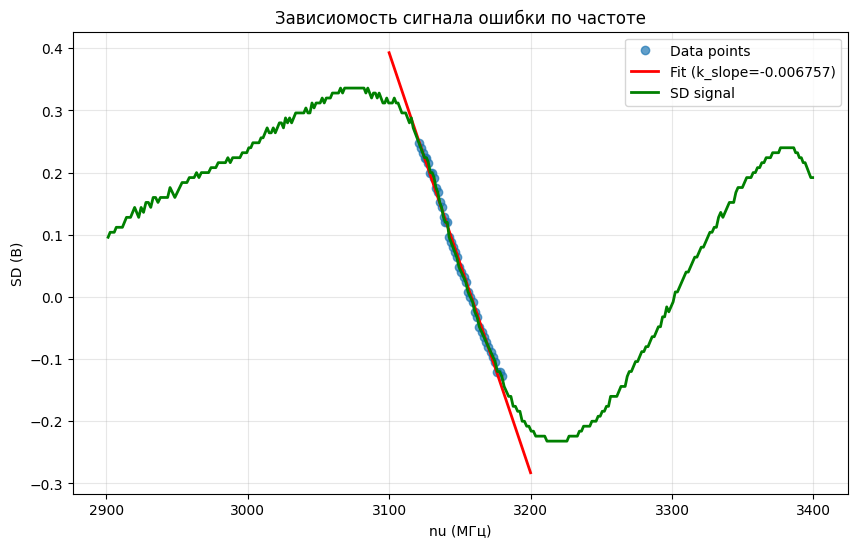

In [16]:
from scipy.stats import linregress

# Фильтруем данные в диапазоне nu от 3250 до 3350
mask_fit = (data_no_p["nu"] >= 3120) & (data_no_p["nu"] <= 3180)
mask_plot = (data_no_p["nu"] >= 2900) & (data_no_p["nu"] <= 3400)
nu_filtered = data_no_p.loc[mask_fit, "nu"]
SD_filtered = data_no_p.loc[mask_fit, "SD"]
nu_plot = data_no_p.loc[mask_plot, "nu"]
SD_plot = data_no_p.loc[mask_plot, "SD"]

# Выполняем линейную регрессию
k_slope, intercept, r_value, p_value, std_err = linregress(nu_filtered, SD_filtered)
k_stab = abs(k_slope)
print(f"Диапазон nu: 3120-3180 МГц")
print(f"Коэффициент наклона (k_slope): {k_slope:.6f}")
print(f"Пересечение с осью y (intercept): {intercept:.6f}")
print(f"R-квадрат: {r_value**2:.6f}")

xs = np.linspace(3100, 3200, 100)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(nu_filtered, SD_filtered, "o", label="Data points", alpha=0.7)
plt.plot(xs, k_slope * xs + intercept, "r-", linewidth=2, label=f"Fit (k_slope={k_slope:.6f})")
plt.plot(nu_plot, SD_plot, "g-", linewidth=2, label=f"SD signal")
plt.xlabel("nu (МГц)")
plt.ylabel("SD (В)")
plt.title(f"Зависиомость сигнала ошибки по частоте")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("stabilization_error_signal_fit.png", dpi=300)
plt.show()

data_stab_lock (Lock):
  SD max: 0.000000 В
  SD min: -0.024000 В
  SD range: 0.024000 В
  RMS ошибки (std SD): 0.005789 В
  Freq range (SD_range/k_slope): 3.551938 МГц

data_stab_ad_gain (Additional Gain):
  SD max: 0.224000 В
  SD min: -0.200000 В
  SD range: 0.424000 В
  RMS ошибки (std SD): 0.126124 В
  Freq range (SD_range/k_slope): 62.750909 МГц

Сравнение RMS ошибок:
  Улучшение: 0.05x


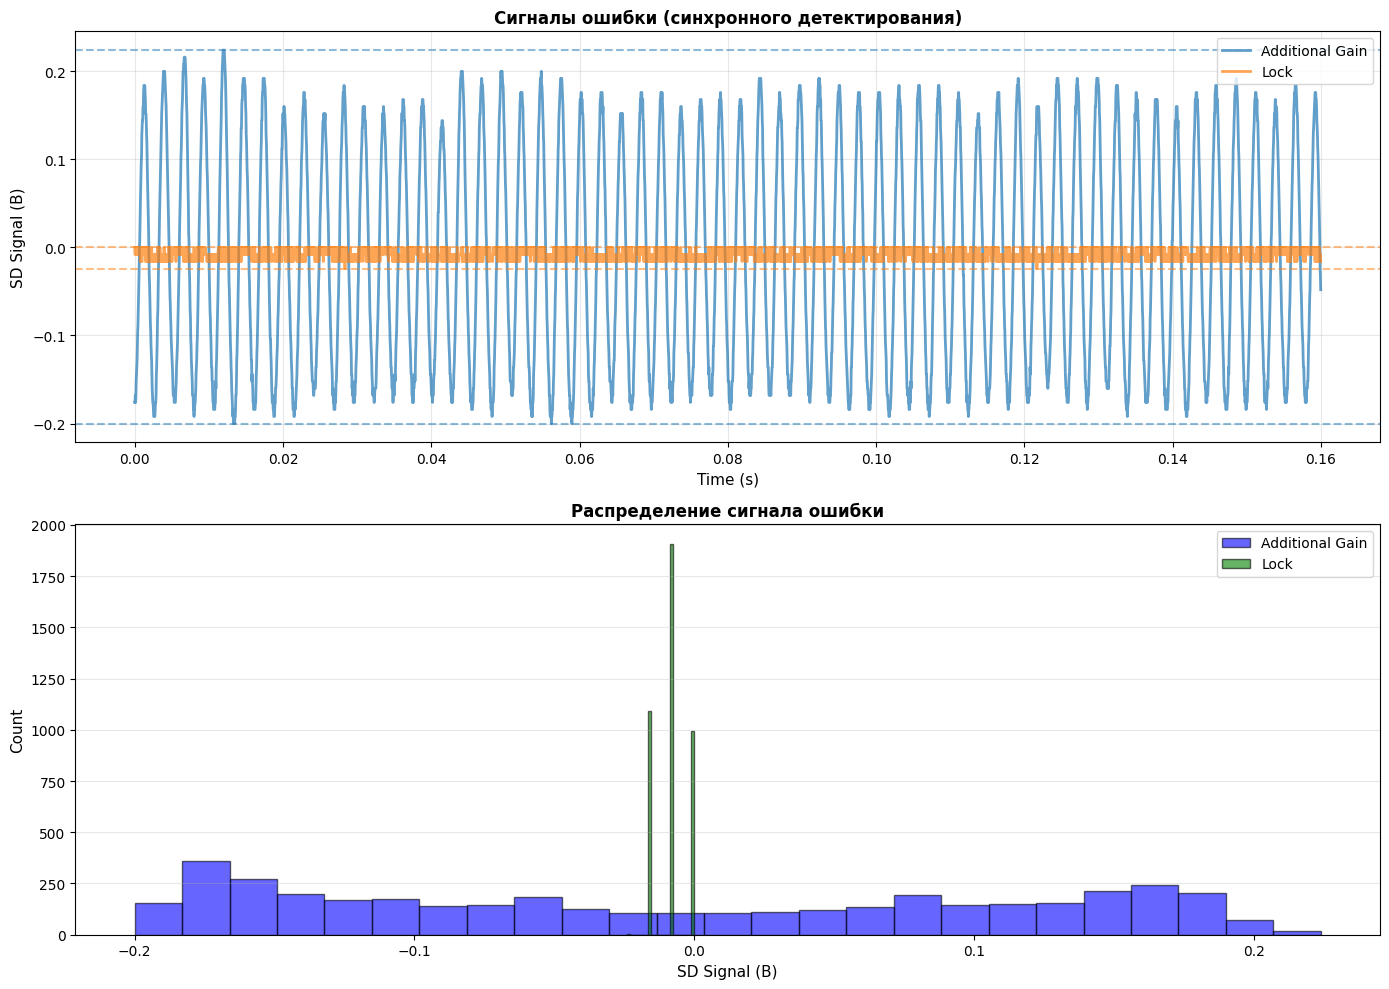

In [23]:
# Находим max и min канала SD в data_stab_lock
SD_max_lock = data_stab_lock["SD"].max()
SD_min_lock = data_stab_lock["SD"].min()
SD_range_lock = SD_max_lock - SD_min_lock
freq_range_lock = SD_range_lock / k_stab
rms_error_lock = data_stab_lock["SD"].std()

print("data_stab_lock (Lock):")
print(f"  SD max: {SD_max_lock:.6f} В")
print(f"  SD min: {SD_min_lock:.6f} В")
print(f"  SD range: {SD_range_lock:.6f} В")
print(f"  RMS ошибки (std SD): {rms_error_lock:.6f} В")
print(f"  Freq range (SD_range/k_slope): {freq_range_lock:.6f} МГц")

# Находим max и min канала SD в data_stab_ad_gain
SD_max_ad_gain = data_stab_ad_gain["SD"].max()
SD_min_ad_gain = data_stab_ad_gain["SD"].min()
SD_range_ad_gain = SD_max_ad_gain - SD_min_ad_gain
freq_range_ad_gain = SD_range_ad_gain / k_stab
rms_error_ad_gain = data_stab_ad_gain["SD"].std()

print("\ndata_stab_ad_gain (Additional Gain):")
print(f"  SD max: {SD_max_ad_gain:.6f} В")
print(f"  SD min: {SD_min_ad_gain:.6f} В")
print(f"  SD range: {SD_range_ad_gain:.6f} В")
print(f"  RMS ошибки (std SD): {rms_error_ad_gain:.6f} В")
print(f"  Freq range (SD_range/k_slope): {freq_range_ad_gain:.6f} МГц")
print(f"\nСравнение RMS ошибок:")
print(f"  Улучшение: {rms_error_lock/rms_error_ad_gain:.2f}x")

# Сравнительные графики
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# График 1: SD сигналы
ax = axes[0]
ax.plot(data_stab_ad_gain["Time, s"], data_stab_ad_gain["SD"], "-", label="Additional Gain", alpha=0.7, linewidth=2, markersize=3)
ax.plot(data_stab_lock["Time, s"], data_stab_lock["SD"], "-", label="Lock", alpha=0.7, linewidth=2, markersize=3)
ax.axhline(SD_max_lock, color='C1', linestyle='--', alpha=0.5)
ax.axhline(SD_min_lock, color='C1', linestyle='--', alpha=0.5)
ax.axhline(SD_max_ad_gain, color='C0', linestyle='--', alpha=0.5)
ax.axhline(SD_min_ad_gain, color='C0', linestyle='--', alpha=0.5)
ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("SD Signal (В)", fontsize=11)
ax.set_title("Сигналы ошибки (синхронного детектирования)", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# График 2: Гистограммы SD
ax = axes[1]
ax.hist(data_stab_ad_gain["SD"], bins=25, alpha=0.6, label="Additional Gain", color='blue', edgecolor='black')
ax.hist(data_stab_lock["SD"], bins=25, alpha=0.6, label="Lock", color='green', edgecolor='black')
ax.set_xlabel("SD Signal (В)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Распределение сигнала ошибки", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("stabilization_comparison.png", dpi=300)
plt.show()


Sampling rate AD: 25000.00000000102 Hz
Sampling rate LOCK: 25000.00000000102 Hz


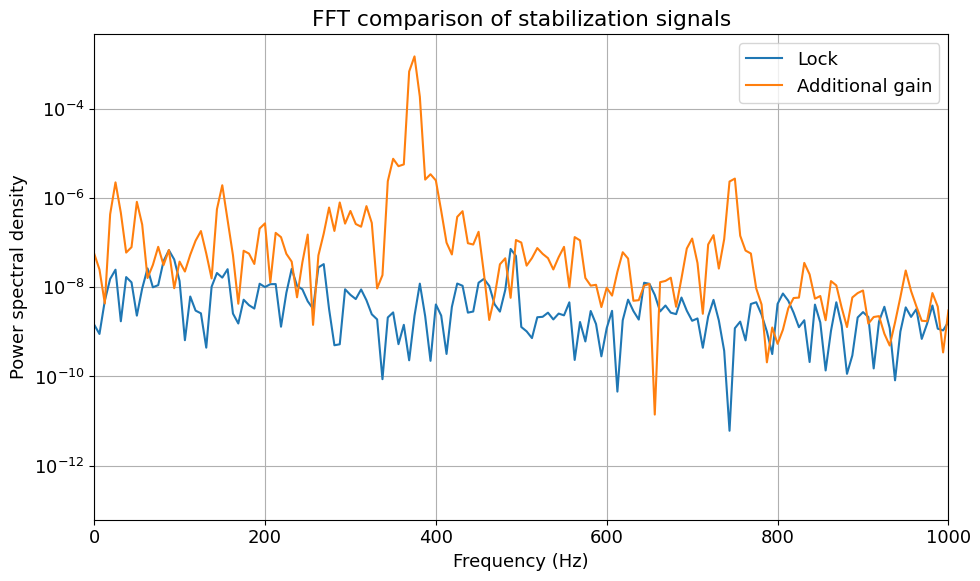

Peak frequency from PSD: 375.0000000000153 Hz
Fitted frequency: 373.677 Hz
Period: 0.002676 s


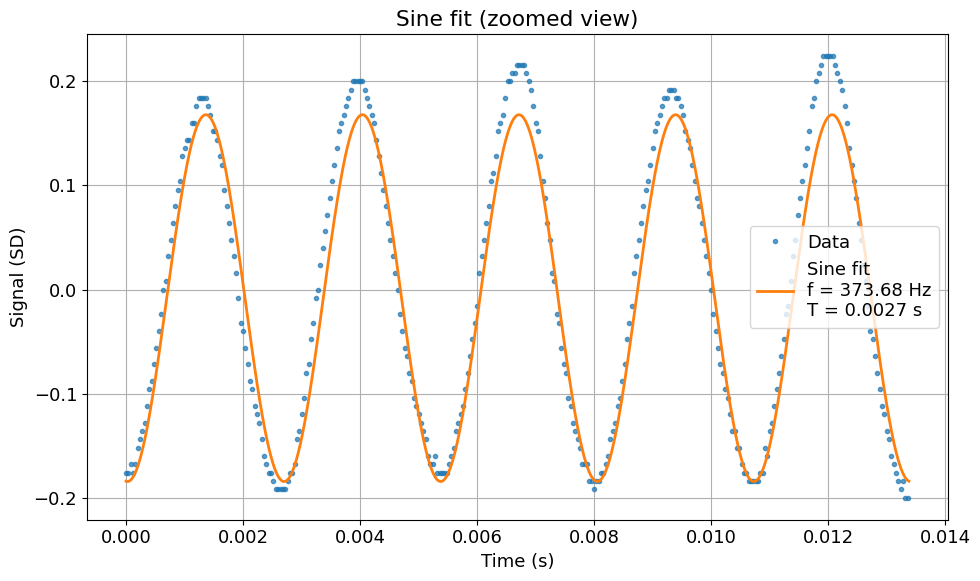

In [28]:
from scipy.signal import welch
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 13,
    "figure.figsize": (10,6),
    "axes.grid": True
})

# Helper to compute sampling frequency
def _compute_fs(t):
    dt = np.diff(t)
    dt = dt[~np.isnan(dt)]
    if len(dt) == 0:
        return 1.0
    return 1.0 / np.median(dt)

# Ensure SD column exists
if 'SD' not in data_stab_ad_gain.columns:
    if 'V_2' in data_stab_ad_gain.columns:
        data_stab_ad_gain['SD'] = data_stab_ad_gain['V_2']
    else:
        data_stab_ad_gain['SD'] = data_stab_ad_gain.iloc[:,1]

if 'SD' not in data_stab_lock.columns:
    if 'V_2' in data_stab_lock.columns:
        data_stab_lock['SD'] = data_stab_lock['V_2']
    else:
        data_stab_lock['SD'] = data_stab_lock.iloc[:,1]

t_ad = data_stab_ad_gain['Time, s'].values
t_lock = data_stab_lock['Time, s'].values
y_ad = data_stab_ad_gain['SD'].values
y_lock = data_stab_lock['SD'].values

fs_ad = _compute_fs(t_ad)
fs_lock = _compute_fs(t_lock)

print("Sampling rate AD:", fs_ad, "Hz")
print("Sampling rate LOCK:", fs_lock, "Hz")

nperseg_ad = min(4096, max(64, len(y_ad)))
nperseg_lock = min(4096, max(64, len(y_lock)))

f_ad, Pxx_ad = welch(y_ad, fs=fs_ad, nperseg=nperseg_ad)
f_lock, Pxx_lock = welch(y_lock, fs=fs_lock, nperseg=nperseg_lock)

# ========================
# FFT Plot
# ========================
plt.figure()

plt.semilogy(f_lock, Pxx_lock, label='Lock')
plt.semilogy(f_ad, Pxx_ad, label='Additional gain')

plt.xlim(0, 1000)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power spectral density')
plt.title('FFT comparison of stabilization signals')

plt.legend()
plt.tight_layout()
plt.savefig('stab_fft_comparison.png', dpi=300)
plt.show()

# Find peak
peak_idx = np.nanargmax(Pxx_ad)
peak_freq = f_ad[peak_idx]

print('Peak frequency from PSD:', peak_freq, 'Hz')

# ========================
# Sine fit
# ========================
t0 = t_ad - t_ad[0]

mask = ~np.isnan(t0) & ~np.isnan(y_ad)
t_fit = t0[mask]
y_fit = y_ad[mask]

def _sine(t, A, f, phi, offset):
    return A * np.sin(2 * np.pi * f * t + phi) + offset

A0 = 0.5 * (np.nanmax(y_fit) - np.nanmin(y_fit))
f0 = peak_freq if peak_freq > 0 else 1.0
phi0 = 0.0
offset0 = np.nanmean(y_fit)

try:
    popt, pcov = curve_fit(
        _sine, t_fit, y_fit,
        p0=[A0, f0, phi0, offset0],
        maxfev=20000
    )

    fitted_freq = popt[1]
    period = 1.0 / fitted_freq

    print(f'Fitted frequency: {fitted_freq:.3f} Hz')
    print(f'Period: {period:.6f} s')

    # Zoomed time window (несколько периодов)
    zoom_periods = 5
    t_min = t_fit.min()
    t_max = t_min + zoom_periods * period

    mask_zoom = (t_fit >= t_min) & (t_fit <= t_max)

    tt = np.linspace(t_min, t_max, 2000)

    # ========================
    # Plot zoomed sine fit
    # ========================
    plt.figure()

    plt.plot(
        t_fit[mask_zoom],
        y_fit[mask_zoom],
        '.',
        label='Data',
        alpha=0.7
    )

    plt.plot(
        tt,
        _sine(tt, *popt),
        '-',
        linewidth=2,
        label=f'Sine fit\nf = {fitted_freq:.2f} Hz\nT = {period:.4f} s'
    )

    plt.xlabel('Time (s)')
    plt.ylabel('Signal (SD)')
    plt.title('Sine fit (zoomed view)')

    plt.legend()
    plt.tight_layout()

    plt.savefig('stab_ad_gain_sine_fit.png', dpi=300)
    plt.show()

except Exception as e:
    print('Sine fit failed:', e)